In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [2]:
np.random.seed(42)
data = {
    'age': np.random.randint(18, 65, 200),
    'monthly_charges': np.random.uniform(20, 100, 200),
    'tenure_months': np.random.randint(1, 72, 200),
    'num_products': np.random.randint(1, 5, 200),
    'churned': np.random.randint(0, 2, 200)
}
df = pd.DataFrame(data)
print(df.head(10))
print("\nChurn distribution:")
print(df['churned'].value_counts())

   age  monthly_charges  tenure_months  num_products  churned
0   56        40.142584             39             3        0
1   46        59.779880             33             1        0
2   32        44.070265             23             2        0
3   60        42.787240             10             3        1
4   25        22.950956             69             3        1
5   38        68.765147             34             1        1
6   56        60.214322             52             1        1
7   36        24.118300             10             1        1
8   40        42.291717             19             2        0
9   28        92.661271             58             1        1

Churn distribution:
churned
1    102
0     98
Name: count, dtype: int64


In [3]:
X = df[['age', 'monthly_charges', 'tenure_months', 'num_products']]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained! ✅")

Model trained! ✅


In [4]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 60.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.55      0.60        22
           1       0.55      0.67      0.60        18

    accuracy                           0.60        40
   macro avg       0.61      0.61      0.60        40
weighted avg       0.61      0.60      0.60        40



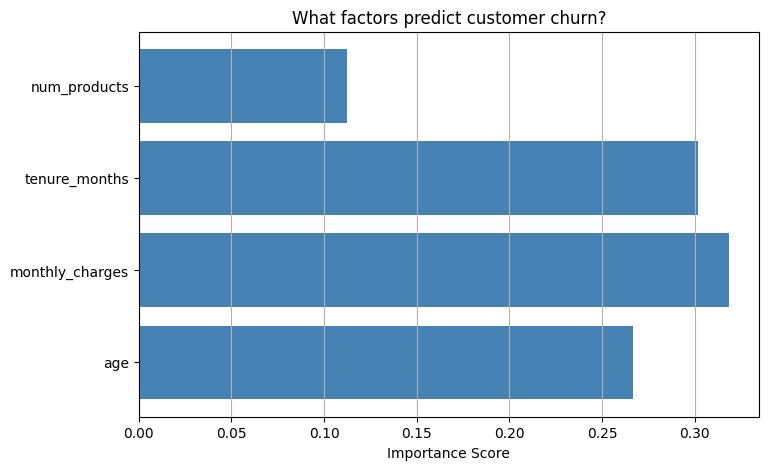

In [5]:
features = ['age', 'monthly_charges', 'tenure_months', 'num_products']
importance = model.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(features, importance, color='steelblue')
plt.xlabel('Importance Score')
plt.title('What factors predict customer churn?')
plt.grid(axis='x')
plt.show()

In [6]:
new_customer = pd.DataFrame({
    'age': [45],
    'monthly_charges': [85.0],
    'tenure_months': [3],
    'num_products': [1]
})
prediction = model.predict(new_customer)
probability = model.predict_proba(new_customer)[0][1]

print(f"Churn prediction: {'Will churn ⚠️' if prediction[0] == 1 else 'Will stay ✅'}")
print(f"Churn probability: {probability * 100:.1f}%")

Churn prediction: Will churn ⚠️
Churn probability: 78.0%
